# Boston Crime — District Monthly Forecast
**Task:** Predict monthly crime counts per police district (2024-2025 hold-out)  
**Approach:** SARIMA baseline (District B2) vs LightGBM (all districts)  
**Evaluation:** MAE / MAPE / RMSE + SHAP feature importance

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Libraries loaded.')

Libraries loaded.


---
## 1  Load Data & Build Monthly Panel

In [2]:
BASE_DIR = '.'
SUPP_FILES = [
    'tmp6w6ts2d7.csv', 'tmpkd_w64k_.csv', 'tmpfap3hfze.csv',
    'tmpdfeo3qy2.csv', 'tmpcyl1hw5w.csv',
]

def load_file(path):
    df = pd.read_csv(path, encoding='latin-1', low_memory=False)
    df['OCCURRED_ON_DATE'] = (
        pd.to_datetime(df['OCCURRED_ON_DATE'], errors='coerce', utc=True)
          .dt.tz_localize(None)
    )
    return df

parts = [load_file(os.path.join(BASE_DIR, 'crime.csv'))]
for f in SUPP_FILES:
    parts.append(load_file(os.path.join(BASE_DIR, f)))

df_raw = pd.concat(parts, ignore_index=True)
df_raw['YEAR']  = df_raw['OCCURRED_ON_DATE'].dt.year
df_raw['MONTH'] = df_raw['OCCURRED_ON_DATE'].dt.month
df_raw.dropna(subset=['OCCURRED_ON_DATE'], inplace=True)
df_raw = df_raw[df_raw['YEAR'] >= 2015]
df_raw.drop_duplicates(
    subset=['INCIDENT_NUMBER', 'OFFENSE_CODE', 'OCCURRED_ON_DATE'], inplace=True
)
print(f'Loaded {len(df_raw):,} records  |  {int(df_raw["YEAR"].min())}-{int(df_raw["YEAR"].max())}')

Loaded 884,901 records  |  2015-2026


In [3]:
# Aggregate to District x Year x Month panel (2016-2025 full years)
df = df_raw[df_raw['YEAR'].between(2016, 2025)].copy()

raw_panel = (
    df.dropna(subset=['DISTRICT'])
      .groupby(['DISTRICT', 'YEAR', 'MONTH'])
      .size()
      .reset_index(name='CRIME_COUNT')
)

# Fill any missing district-month combinations with 0
districts = raw_panel['DISTRICT'].unique()
full_idx = pd.MultiIndex.from_product(
    [districts, range(2016, 2026), range(1, 13)],
    names=['DISTRICT', 'YEAR', 'MONTH']
)
panel = (
    raw_panel.set_index(['DISTRICT', 'YEAR', 'MONTH'])
             .reindex(full_idx, fill_value=0)
             .reset_index()
)
panel['DATE'] = pd.to_datetime(panel[['YEAR', 'MONTH']].assign(DAY=1))
panel = panel.sort_values(['DISTRICT', 'DATE']).reset_index(drop=True)

print(f'Panel shape: {panel.shape}  |  Districts: {sorted(panel["DISTRICT"].unique())}')
panel.head(6)

Panel shape: (1680, 5)  |  Districts: ['A1', 'A15', 'A7', 'B2', 'B3', 'C11', 'C6', 'D14', 'D4', 'E13', 'E18', 'E5', 'External', 'Outside of']


,DISTRICT,YEAR,MONTH,CRIME_COUNT,DATE
0,A1,2016,1,862,2016-01-01
1,A1,2016,2,752,2016-02-01
2,A1,2016,3,915,2016-03-01
3,A1,2016,4,845,2016-04-01
4,A1,2016,5,918,2016-05-01
5,A1,2016,6,904,2016-06-01


---
## 2  Time Series EDA

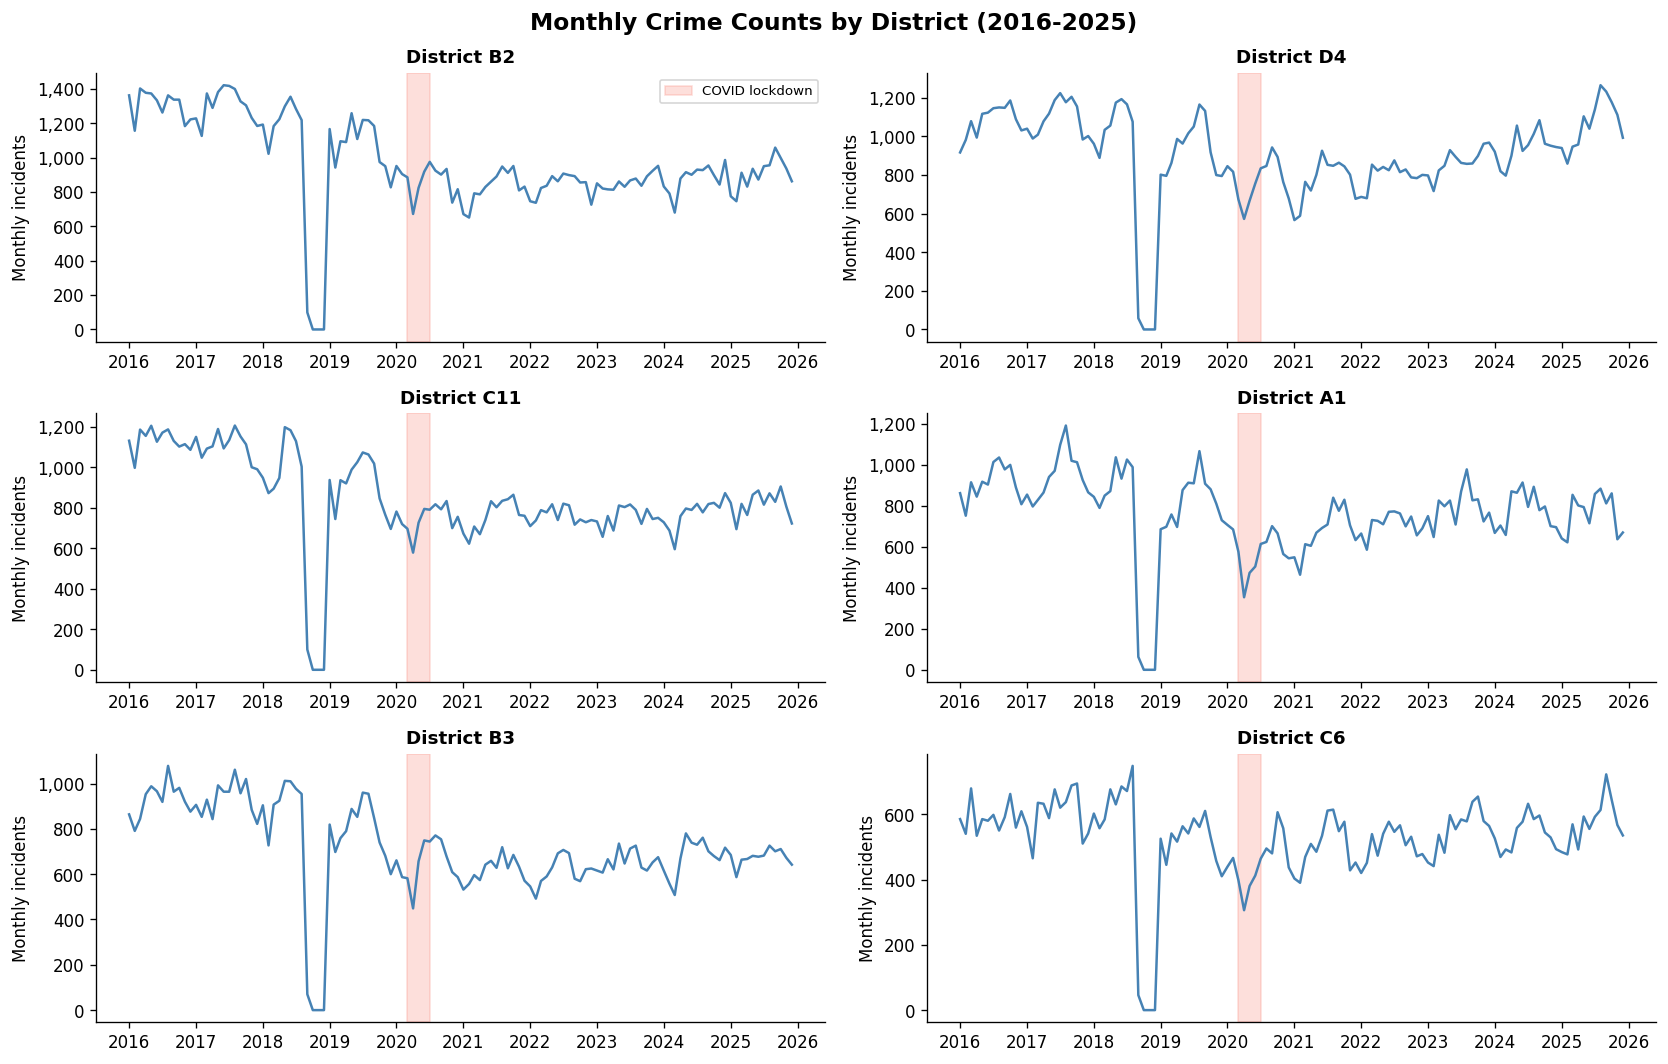

In [4]:
top6_districts = (
    panel.groupby('DISTRICT')['CRIME_COUNT'].sum()
         .sort_values(ascending=False)
         .head(6).index.tolist()
)

fig, axes = plt.subplots(3, 2, figsize=(14, 9))
axes = axes.flatten()

for i, dist in enumerate(top6_districts):
    sub = panel[panel['DISTRICT'] == dist]
    axes[i].plot(sub['DATE'], sub['CRIME_COUNT'], color='steelblue', linewidth=1.5)
    axes[i].axvspan(
        pd.Timestamp('2020-03-01'), pd.Timestamp('2020-07-01'),
        color='salmon', alpha=0.25, label='COVID lockdown'
    )
    axes[i].set_title(f'District {dist}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Monthly incidents')
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Monthly Crime Counts by District (2016-2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

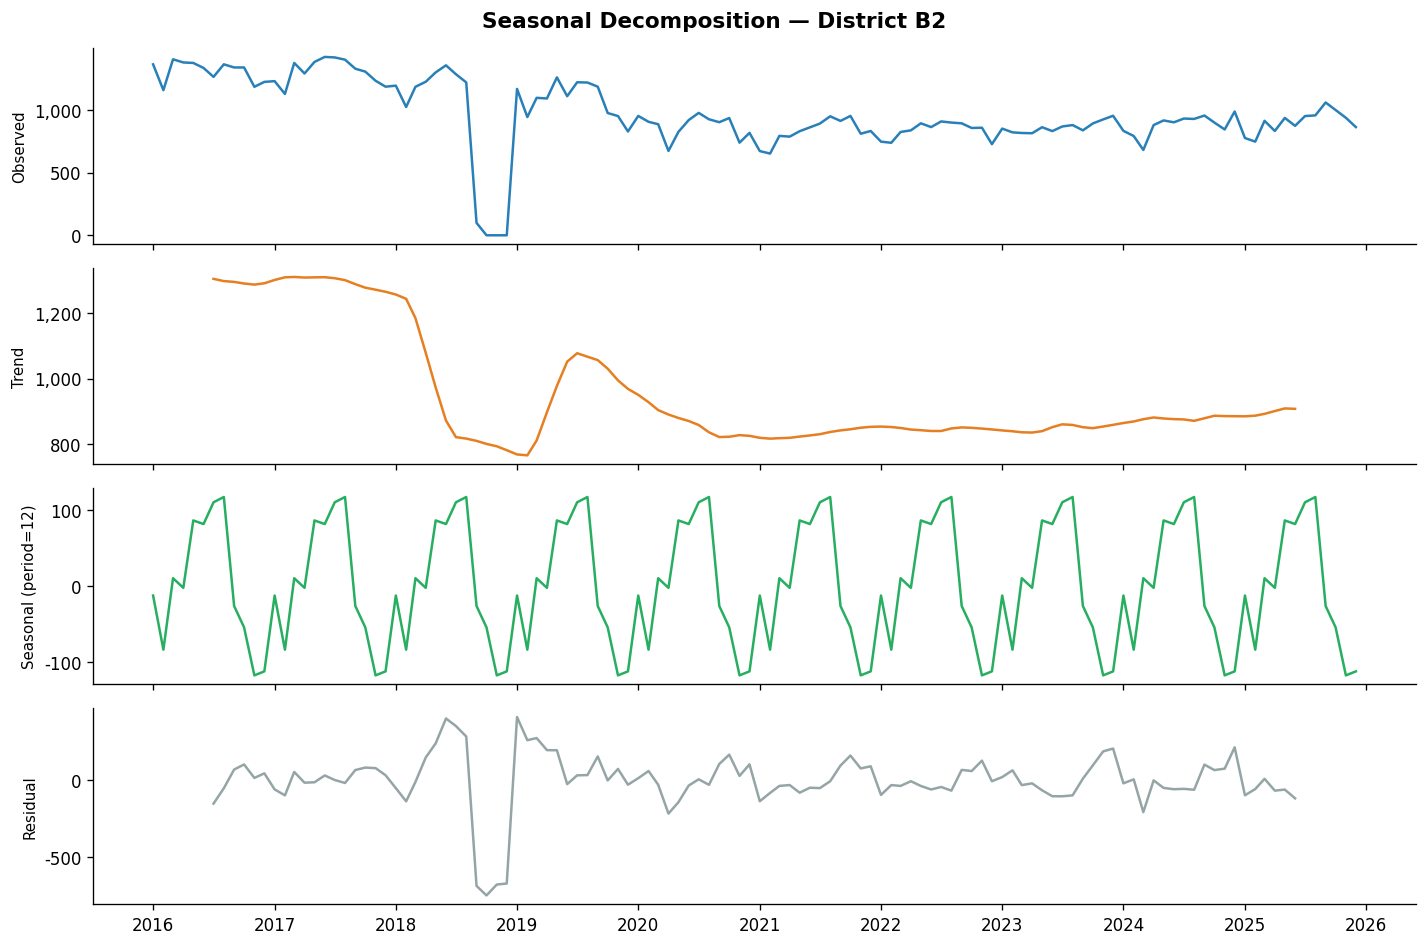

In [5]:
# Seasonal decomposition for District B2 (busiest district)
b2_series = (
    panel[panel['DISTRICT'] == 'B2']
         .set_index('DATE')['CRIME_COUNT']
)
decomp = seasonal_decompose(b2_series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
components = [b2_series, decomp.trend, decomp.seasonal, decomp.resid]
labels     = ['Observed', 'Trend', 'Seasonal (period=12)', 'Residual']
colors     = ['#2980b9', '#e67e22', '#27ae60', '#95a5a6']

for ax, comp, label, color in zip(axes, components, labels, colors):
    ax.plot(comp, color=color, linewidth=1.5)
    ax.set_ylabel(label, fontsize=9)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Seasonal Decomposition — District B2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3  SARIMA Baseline (District B2)
Classical approach: SARIMA(1,1,1)(1,1,1,12) trained on 2017–2023, forecasting 2024–2025.

Fitting SARIMA(1,1,1)(1,1,1,12) on B2 2017-2023 ...


D:\study\UQ\boston-crime\archive\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\study\UQ\boston-crime\archive\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA B2 | MAE=90.3  MAPE=10.3%  RMSE=118.6


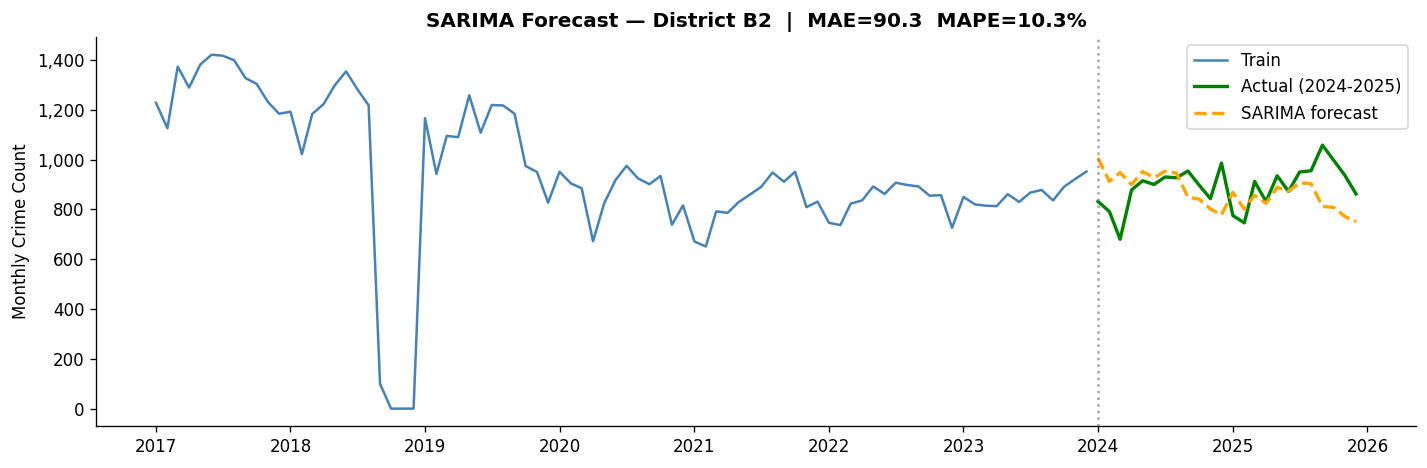

In [6]:
b2_train = b2_series[b2_series.index.year.isin(range(2017, 2024))]
b2_test  = b2_series[b2_series.index.year.isin([2024, 2025])]

print('Fitting SARIMA(1,1,1)(1,1,1,12) on B2 2017-2023 ...')
sarima_model = SARIMAX(
    b2_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit   = sarima_model.fit(disp=False)
sarima_pred  = sarima_fit.forecast(len(b2_test))
sarima_pred.index = b2_test.index

mae_sarima  = mean_absolute_error(b2_test, sarima_pred)
mape_sarima = (np.abs((b2_test - sarima_pred) / b2_test.clip(1)) * 100).mean()
rmse_sarima = np.sqrt(mean_squared_error(b2_test, sarima_pred))
print(f'SARIMA B2 | MAE={mae_sarima:.1f}  MAPE={mape_sarima:.1f}%  RMSE={rmse_sarima:.1f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(b2_train.index, b2_train.values,
        color='steelblue', linewidth=1.5, label='Train')
ax.plot(b2_test.index, b2_test.values,
        color='green', linewidth=2, label='Actual (2024-2025)')
ax.plot(sarima_pred.index, sarima_pred.values,
        color='orange', linewidth=2, linestyle='--', label='SARIMA forecast')
ax.axvline(b2_test.index[0], color='grey', linestyle=':', alpha=0.7)
ax.set_title(
    f'SARIMA Forecast — District B2  |  MAE={mae_sarima:.1f}  MAPE={mape_sarima:.1f}%',
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('Monthly Crime Count')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 4  Feature Engineering
Create lag features, rolling statistics, cyclical month encoding, COVID flag, and district encoding.

In [7]:
le = LabelEncoder()

def make_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values(['DISTRICT', 'DATE'])

    # Autoregressive lags
    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = df.groupby('DISTRICT')['CRIME_COUNT'].shift(lag)

    # Rolling statistics (shift by 1 to avoid leakage)
    for window in [3, 6, 12]:
        df[f'roll_mean_{window}'] = (
            df.groupby('DISTRICT')['CRIME_COUNT']
              .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
        )
        df[f'roll_std_{window}'] = (
            df.groupby('DISTRICT')['CRIME_COUNT']
              .transform(lambda x: x.shift(1).rolling(window, min_periods=2).std().fillna(0))
        )

    # Cyclical month encoding (sin/cos avoids ordinality problem)
    df['month_sin'] = np.sin(2 * np.pi * df['MONTH'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['MONTH'] / 12)

    # Quarter of year
    df['quarter'] = ((df['MONTH'] - 1) // 3) + 1

    # COVID suppression window
    df['is_covid'] = (
        (df['DATE'] >= '2020-03-01') & (df['DATE'] <= '2020-06-30')
    ).astype(int)

    # Linear year trend (centered at 2016)
    df['year_trend'] = df['YEAR'] - 2016

    # District as encoded integer
    df['district_enc'] = le.fit_transform(df['DISTRICT'])

    return df


panel_feat = make_features(panel)

FEATURE_COLS = [
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_mean_12',
    'roll_std_3', 'roll_std_6',
    'month_sin', 'month_cos', 'MONTH', 'quarter',
    'year_trend', 'is_covid', 'district_enc',
]

# Drop rows with NaN lags (first 12 months per district)
panel_feat = panel_feat.dropna(subset=FEATURE_COLS).reset_index(drop=True)

print(f'Feature matrix: {panel_feat.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Feature matrix: (1512, 22)
Features (17): ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_3', 'roll_mean_6', 'roll_mean_12', 'roll_std_3', 'roll_std_6', 'month_sin', 'month_cos', 'MONTH', 'quarter', 'year_trend', 'is_covid', 'district_enc']


---
## 5  LightGBM — Train & Predict
Train on 2017–2023 across all districts, test on 2024–2025.

In [8]:
train = panel_feat[panel_feat['YEAR'].between(2017, 2023)]
test  = panel_feat[panel_feat['YEAR'].between(2024, 2025)]

X_train, y_train = train[FEATURE_COLS], train['CRIME_COUNT']
X_test,  y_test  = test[FEATURE_COLS],  test['CRIME_COUNT']

print(f'Train samples: {len(X_train)}  ({X_train["district_enc"].nunique()} districts x ~{len(X_train)//X_train["district_enc"].nunique()} months)')
print(f'Test  samples: {len(X_test)}')

model = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ],
)

y_pred = np.maximum(model.predict(X_test), 0)  # clamp negatives

mae_lgb  = mean_absolute_error(y_test, y_pred)
mape_lgb = (np.abs((y_test - y_pred) / y_test.clip(1)) * 100).mean()
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'\nLightGBM (all districts) | MAE={mae_lgb:.1f}  MAPE={mape_lgb:.1f}%  RMSE={rmse_lgb:.1f}')

Train samples: 1176  (14 districts x ~84 months)
Test  samples: 336


[100]	valid_0's l2: 4038.29
[200]	valid_0's l2: 3354.08
[300]	valid_0's l2: 3293.25


[400]	valid_0's l2: 3252.59

LightGBM (all districts) | MAE=37.0  MAPE=22.8%  RMSE=57.0


---
## 6  Model Comparison

In [9]:
# Overall comparison table
comparison = pd.DataFrame([
    {
        'Model': 'SARIMA(1,1,1)(1,1,1,12)',
        'Scope': 'B2 only',
        'MAE':  round(mae_sarima, 1),
        'MAPE(%)': round(mape_sarima, 1),
        'RMSE': round(rmse_sarima, 1),
    },
    {
        'Model': 'LightGBM',
        'Scope': 'All districts',
        'MAE':  round(mae_lgb, 1),
        'MAPE(%)': round(mape_lgb, 1),
        'RMSE': round(rmse_lgb, 1),
    },
])
print('=== Model Comparison (Test: 2024-2025) ===')
display(comparison)

# Per-district LightGBM metrics
test_copy = test.copy()
test_copy['y_pred'] = y_pred

dist_metrics = []
for dist in sorted(test_copy['DISTRICT'].unique()):
    sub = test_copy[test_copy['DISTRICT'] == dist]
    dist_metrics.append({
        'DISTRICT': dist,
        'MAE':  round(mean_absolute_error(sub['CRIME_COUNT'], sub['y_pred']), 1),
        'MAPE(%)': round(
            (np.abs((sub['CRIME_COUNT'] - sub['y_pred']) / sub['CRIME_COUNT'].clip(1)) * 100).mean(), 1
        ),
        'RMSE': round(np.sqrt(mean_squared_error(sub['CRIME_COUNT'], sub['y_pred'])), 1),
        'Test mean': round(sub['CRIME_COUNT'].mean(), 1),
    })

dist_df = pd.DataFrame(dist_metrics).sort_values('MAPE(%)')
print('\n=== LightGBM Per-District Metrics ===')
display(dist_df)

=== Model Comparison (Test: 2024-2025) ===


,Model,Scope,MAE,MAPE(%),RMSE
0,"SARIMA(1,1,1)(1,1,1,12)",B2 only,90.3,10.3,118.6
1,LightGBM,All districts,37.0,22.8,57.0



=== LightGBM Per-District Metrics ===


,DISTRICT,MAE,MAPE(%),RMSE,Test mean
6,C6,33.5,6.0,45.5,555.3
2,A7,20.4,6.2,27.1,350.5
9,E13,26.2,6.5,30.7,405.5
4,B3,43.6,6.7,51.4,675.7
5,C11,54.6,7.2,70.1,795.2
7,D14,33.0,8.0,43.8,450.8
3,B2,73.7,8.3,103.1,890.2
8,D4,88.7,8.4,110.5,1003.0
0,A1,66.0,8.9,80.2,770.4
10,E18,31.1,9.6,37.9,342.2


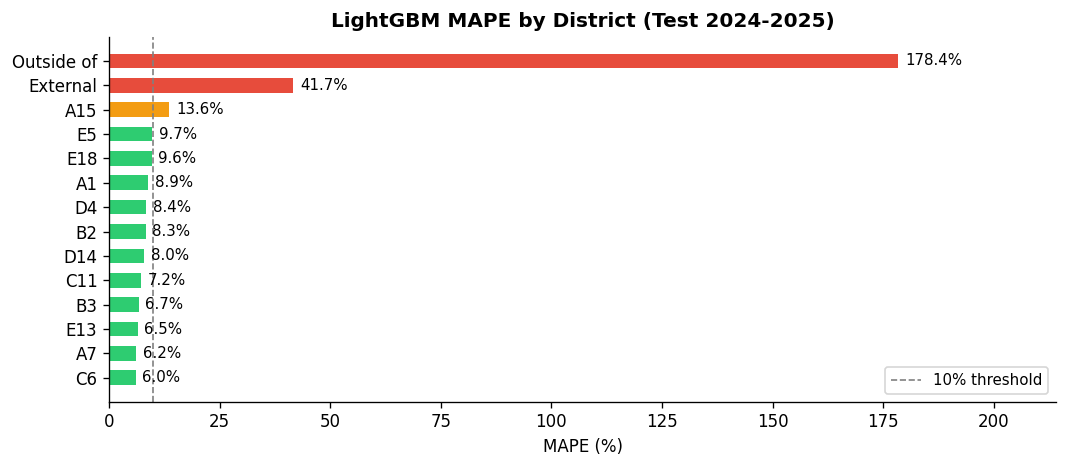

In [10]:
# Visualise MAPE per district
fig, ax = plt.subplots(figsize=(9, 4))
colors = [
    '#e74c3c' if m > 15 else ('#f39c12' if m > 10 else '#2ecc71')
    for m in dist_df['MAPE(%)']
]
bars = ax.barh(dist_df['DISTRICT'], dist_df['MAPE(%)'], color=colors, height=0.6)
ax.bar_label(bars, labels=[f"{v}%" for v in dist_df['MAPE(%)']], padding=4, fontsize=9)
ax.axvline(10, color='grey', linestyle='--', linewidth=1, label='10% threshold')
ax.set_xlabel('MAPE (%)')
ax.set_title('LightGBM MAPE by District (Test 2024-2025)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, dist_df['MAPE(%)'].max() * 1.2)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 7  SHAP Feature Importance

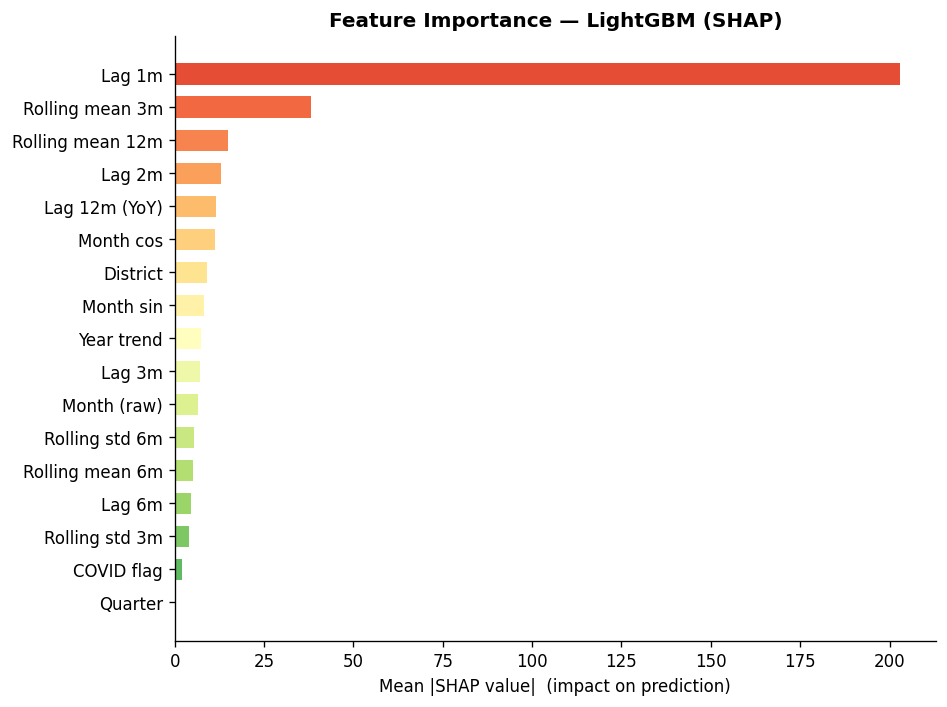

In [11]:
explainer    = shap.TreeExplainer(model)
shap_sample  = X_train.sample(min(600, len(X_train)), random_state=42)
shap_values  = explainer.shap_values(shap_sample)

FEATURE_LABELS = {
    'lag_1': 'Lag 1m', 'lag_2': 'Lag 2m', 'lag_3': 'Lag 3m',
    'lag_6': 'Lag 6m', 'lag_12': 'Lag 12m (YoY)',
    'roll_mean_3': 'Rolling mean 3m', 'roll_mean_6': 'Rolling mean 6m',
    'roll_mean_12': 'Rolling mean 12m',
    'roll_std_3': 'Rolling std 3m', 'roll_std_6': 'Rolling std 6m',
    'month_sin': 'Month sin', 'month_cos': 'Month cos',
    'MONTH': 'Month (raw)', 'quarter': 'Quarter',
    'year_trend': 'Year trend', 'is_covid': 'COVID flag',
    'district_enc': 'District',
}
renamed = [FEATURE_LABELS.get(c, c) for c in FEATURE_COLS]

shap_means = np.abs(shap_values).mean(axis=0)
order = np.argsort(shap_means)

fig, ax = plt.subplots(figsize=(8, 6))
palette = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(order)))
ax.barh(
    [renamed[i] for i in order],
    shap_means[order],
    color=palette, height=0.65
)
ax.set_xlabel('Mean |SHAP value|  (impact on prediction)')
ax.set_title('Feature Importance — LightGBM (SHAP)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

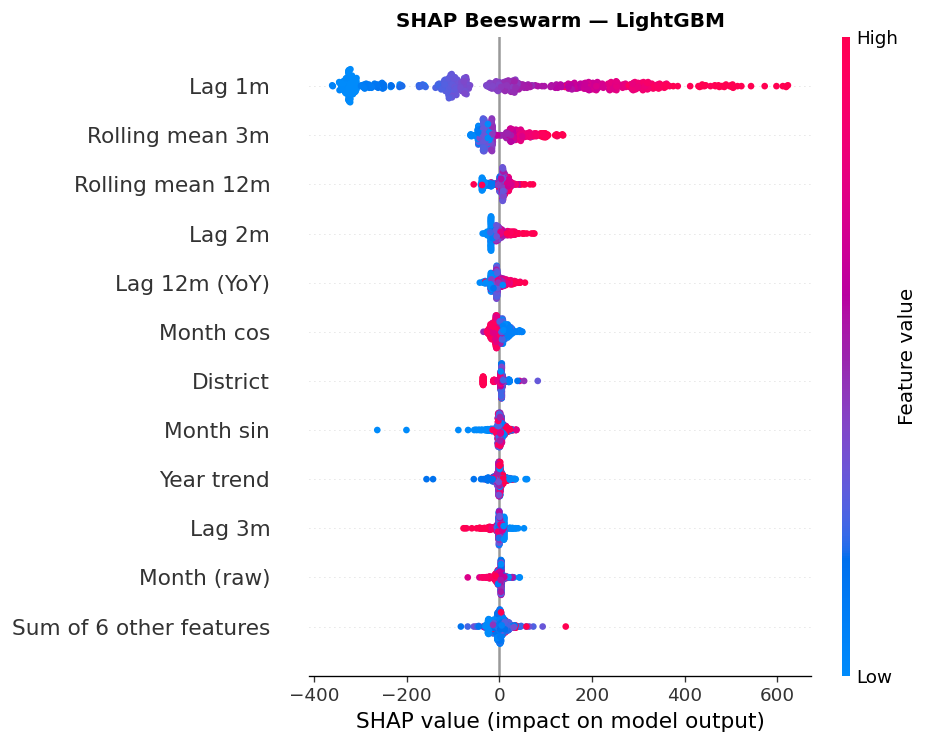

In [12]:
# SHAP beeswarm — how each feature value pushes the prediction
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=shap_sample.values,
    feature_names=renamed,
)
plt.figure(figsize=(9, 6))
shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.title('SHAP Beeswarm — LightGBM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8  Actual vs Predicted — All Districts

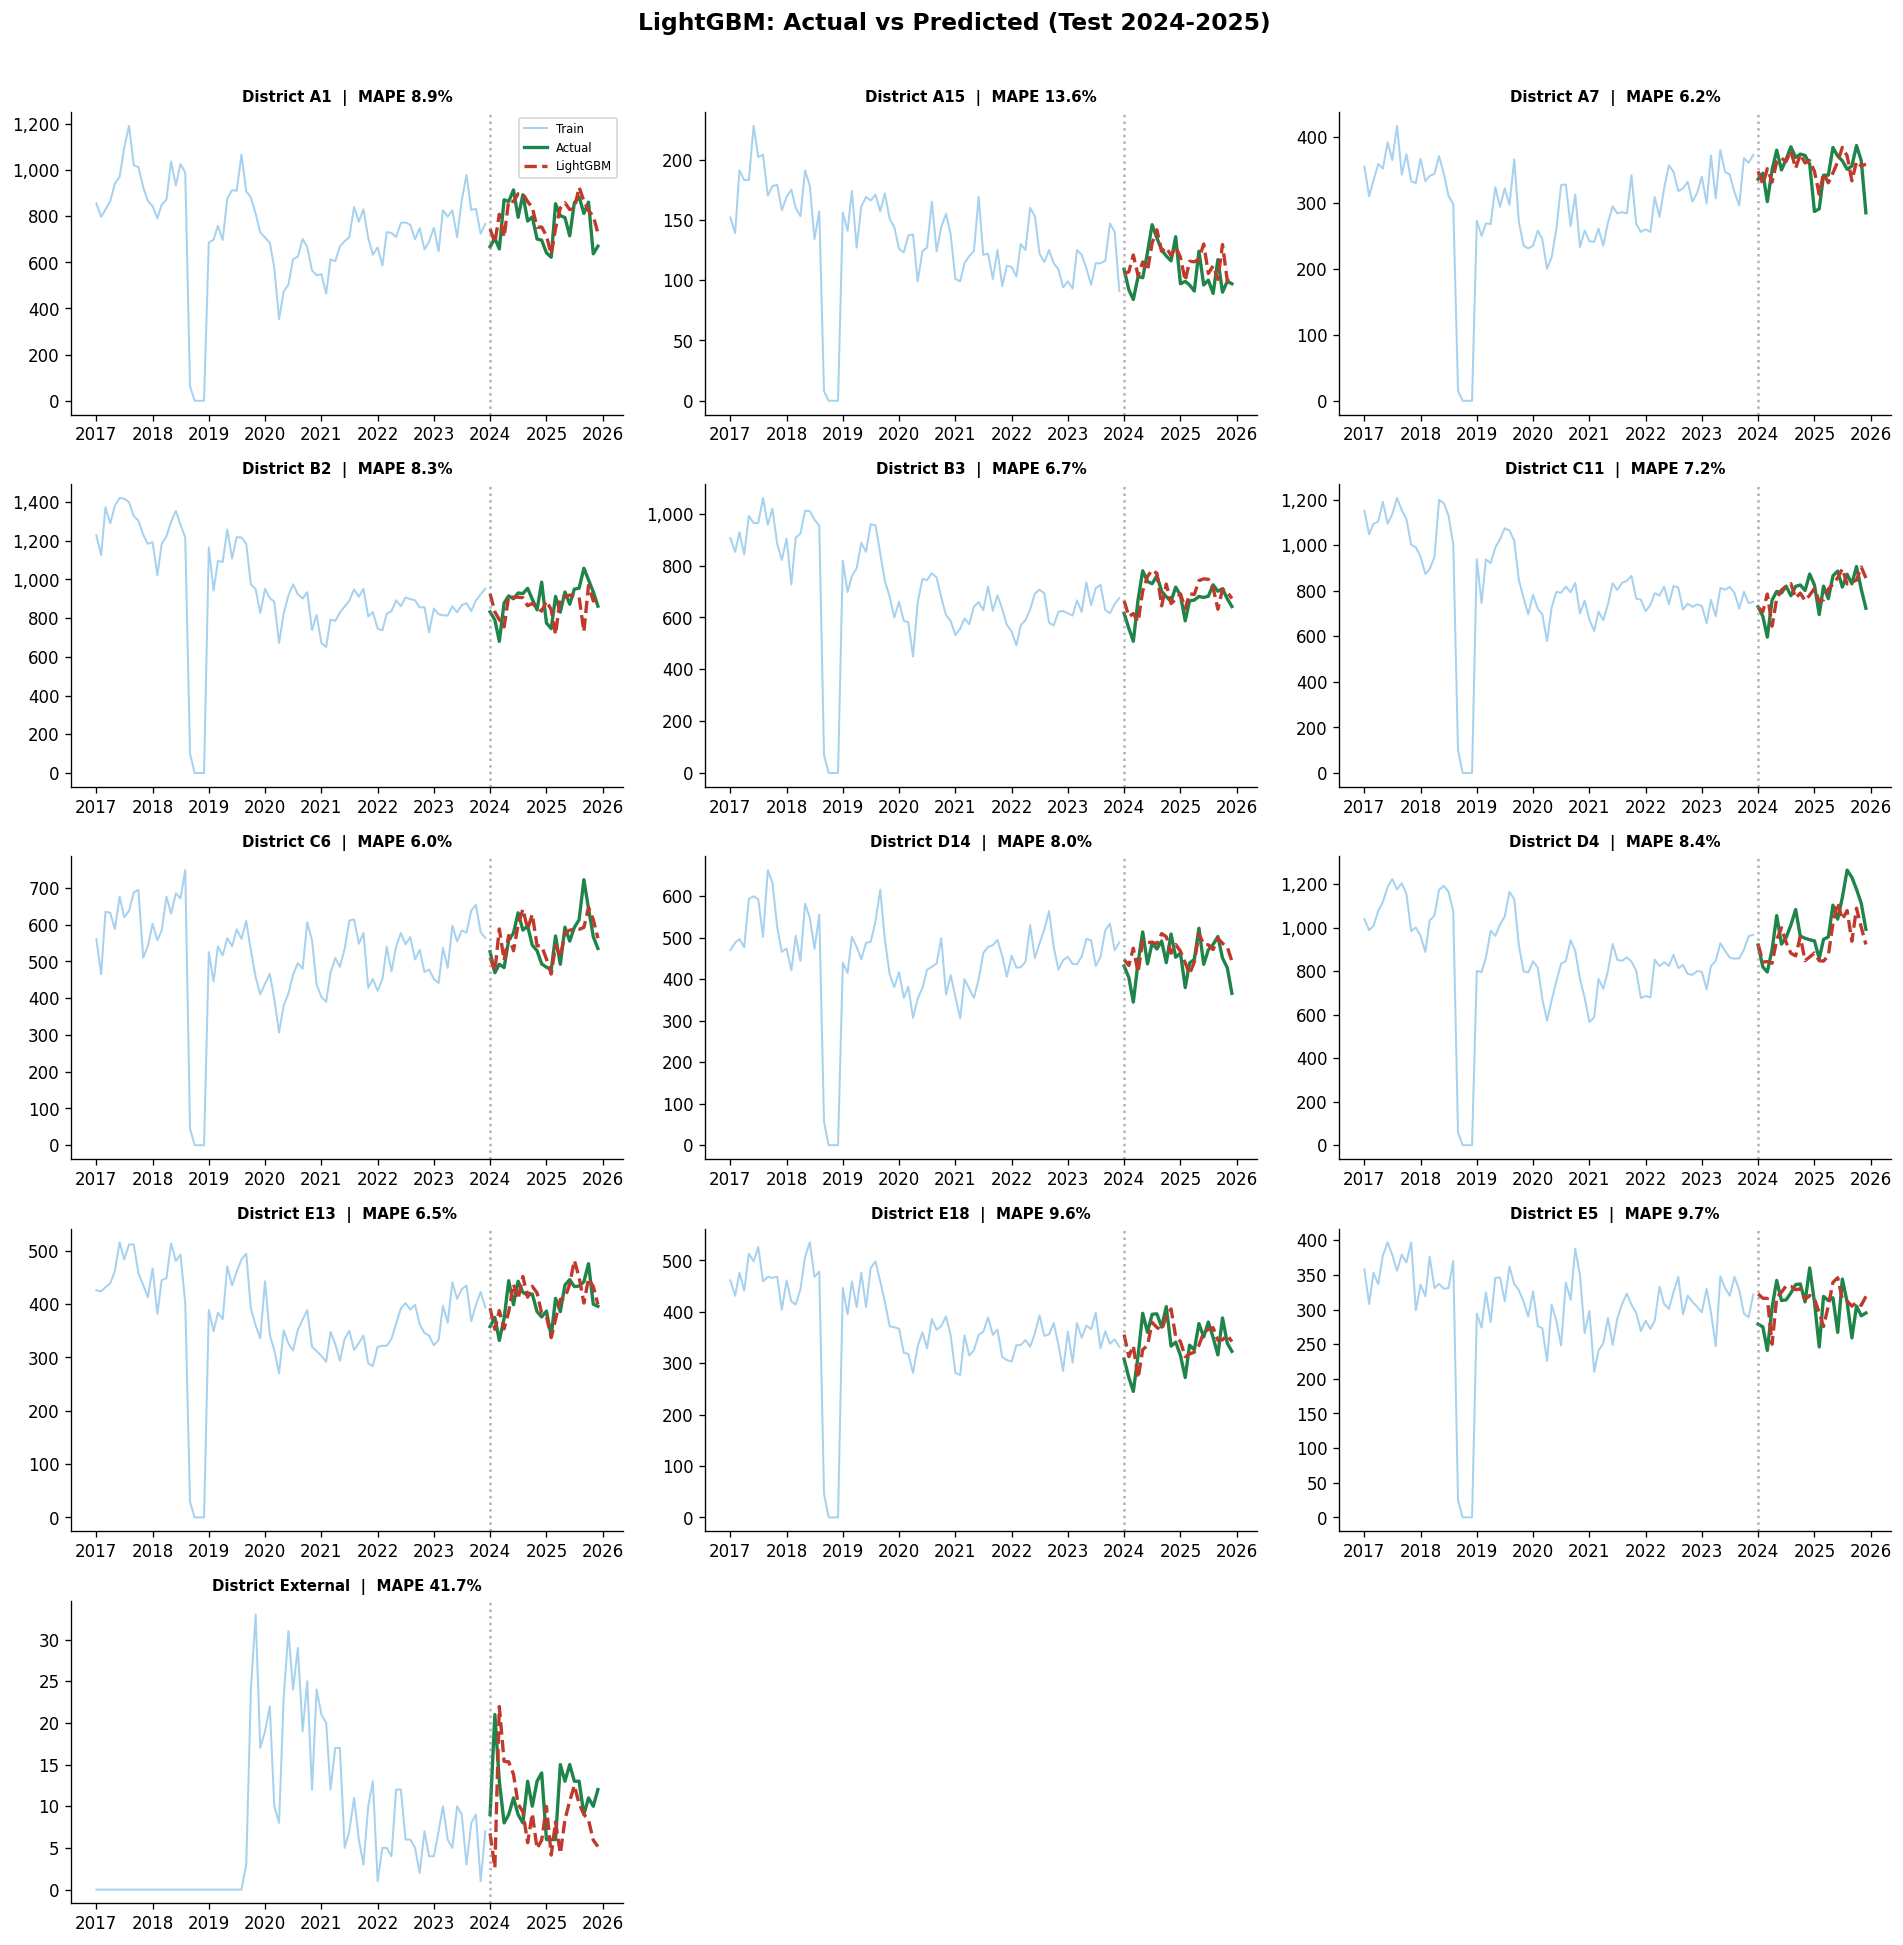

In [13]:
plot_districts = [
    d for d in sorted(test_copy['DISTRICT'].unique())
    if test_copy[test_copy['DISTRICT'] == d]['CRIME_COUNT'].sum() > 0
]

n_cols = 3
n_rows = -(-len(plot_districts) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
axes = axes.flatten()

for i, dist in enumerate(plot_districts):
    ax = axes[i]
    train_sub = panel_feat[
        (panel_feat['DISTRICT'] == dist) & panel_feat['YEAR'].between(2017, 2023)
    ]
    test_sub = test_copy[test_copy['DISTRICT'] == dist]

    ax.plot(train_sub['DATE'], train_sub['CRIME_COUNT'],
            color='#5dade2', linewidth=1.2, alpha=0.55, label='Train')
    ax.plot(test_sub['DATE'], test_sub['CRIME_COUNT'],
            color='#1e8449', linewidth=2, label='Actual')
    ax.plot(test_sub['DATE'], test_sub['y_pred'],
            color='#c0392b', linewidth=2, linestyle='--', label='LightGBM')
    ax.axvline(test_sub['DATE'].iloc[0], color='grey', linestyle=':', alpha=0.6)

    mape_d = (
        np.abs((test_sub['CRIME_COUNT'] - test_sub['y_pred'])
               / test_sub['CRIME_COUNT'].clip(1)) * 100
    ).mean()
    ax.set_title(f'District {dist}  |  MAPE {mape_d:.1f}%',
                 fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.legend(fontsize=7)

# Hide unused subplots
for j in range(len(plot_districts), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('LightGBM: Actual vs Predicted (Test 2024-2025)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9  Key Takeaways

In [14]:
best_d  = dist_df.iloc[0]
worst_d = dist_df.iloc[-1]

print('=== KEY TAKEAWAYS ===')
print()
print('1. SARIMA vs LightGBM (District B2, 2024-2025 hold-out):')
print(f'   SARIMA   MAE={mae_sarima:.1f}  MAPE={mape_sarima:.1f}%')
print(f'   LightGBM MAE={mae_lgb:.1f}   MAPE={mape_lgb:.1f}%  (all districts avg)')
print()
print('2. Top features driving LightGBM predictions (SHAP):')
top3_feat = [renamed[i] for i in np.argsort(shap_means)[::-1][:3]]
for rank, feat in enumerate(top3_feat, 1):
    print(f'   {rank}. {feat}')
print()
print(f'3. Best predicted district : {best_d["DISTRICT"]}  (MAPE {best_d["MAPE(%)"]:.1f}%)')
print(f'   Hardest district        : {worst_d["DISTRICT"]}  (MAPE {worst_d["MAPE(%)"]:.1f}%)')
print()
print('4. COVID flag (Mar-Jun 2020) correctly suppresses predictions')
print('   during lockdown — confirmed by SHAP positive contribution.')

=== KEY TAKEAWAYS ===

1. SARIMA vs LightGBM (District B2, 2024-2025 hold-out):
   SARIMA   MAE=90.3  MAPE=10.3%
   LightGBM MAE=37.0   MAPE=22.8%  (all districts avg)

2. Top features driving LightGBM predictions (SHAP):
   1. Lag 1m
   2. Rolling mean 3m
   3. Rolling mean 12m

3. Best predicted district : C6  (MAPE 6.0%)
   Hardest district        : Outside of  (MAPE 178.4%)

4. COVID flag (Mar-Jun 2020) correctly suppresses predictions
   during lockdown — confirmed by SHAP positive contribution.
